# Secant Method – High Difficulty Version
---
## Learning Objectives
1. Derive Secant iteration formula from Newton’s method.
2. Analyze superlinear convergence.
3. Implement robust Secant algorithm with safeguards.
4. Compare with Newton and Regula Falsi methods.
5. Estimate numerical order of convergence.

## Theoretical Background

The Secant method approximates the derivative in Newton’s method:

$$x_{n+1} = x_n - f(x_n) \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$

It does not require explicit derivative evaluation.

### Convergence
The Secant method converges superlinearly with order ≈ 1.618 (golden ratio).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implement General Secant Method
Include safeguards:
1. Division-by-zero protection
2. Maximum iterations
3. Tolerance on |f(x)| and |x_n - x_{n-1}|


In [2]:
def secant_method(f, x0, x1, tol=1e-10, max_iter=50):
    history = []

    for n in range(1, max_iter+1):
        f0 = f(x0)
        f1 = f(x1)

        if abs(f1 - f0) < 1e-14:
            raise ZeroDivisionError('Denominator too small. Secant fails.')

        x2 = x1 - f1*(x1 - x0)/(f1 - f0)
        history.append((n, x1, f1))

        if abs(f1) < tol or abs(x2 - x1) < tol:
            return x2, history

        x0, x1 = x1, x2

    return x2, history

## Level 1 (Implementation)
Solve:

$$x^3 - x - 2 = 0$$
Initial guesses: $x_0 = 1, x_1 = 2$

In [3]:
def f1(x):
    return x**3 - x - 2

root1, hist1 = secant_method(f1, 1, 2)
root1

1.5213797068045676

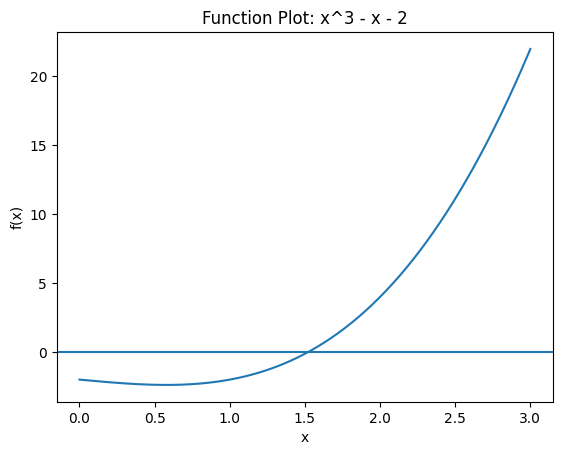

In [4]:
x = np.linspace(0, 3, 400)
y = f1(x)

plt.figure()
plt.plot(x, y)
plt.axhline(0)
plt.title('Function Plot: x^3 - x - 2')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Estimate numerical order of convergence.

In [5]:
exact_root = root1
errors = []

for n, x_val, fx_val in hist1:
    errors.append(abs(x_val - exact_root))

errors

[0.4786202931954324,
 0.1880463734712341,
 0.05869313964038847,
 0.009789725336636801,
 0.00045328628928742454,
 3.3901348237552753e-06,
 1.1803040766977801e-09,
 3.1086244689504383e-15]

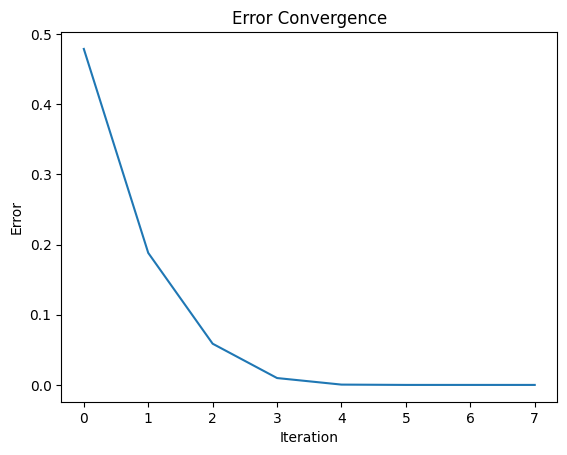

In [6]:
plt.figure()
plt.plot(errors)
plt.title('Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.show()

Try solving:

$$x^3 = 0$$

Discuss behavior near multiple roots.

In [ ]:
def f_fail(x):
    return x**3

# Try:
# secant_method(f_fail, 0.1, 0.2)